In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer

In [6]:
df = pd.read_csv(r"C:\allcoding\market_customer.csv",sep="\t")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [7]:
df.shape

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [8]:
missing = df.isnull().sum()

missing_percent = (missing/len(df))*100

pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
}).sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage
Income,24,1.071429
ID,0,0.000000
Year_Birth,0,0.000000
Education,0,0.000000
Marital_Status,0,0.000000
Kidhome,0,0.000000
Teenhome,0,0.000000
Dt_Customer,0,0.000000
Recency,0,0.000000
MntWines,0,0.000000


In [9]:
df.dropna(inplace=True)

In [14]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [15]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [16]:
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

0


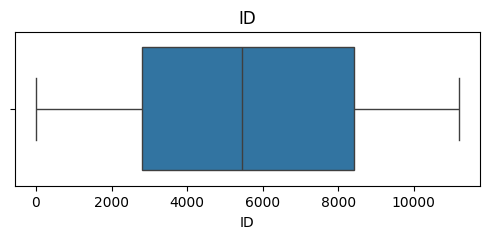

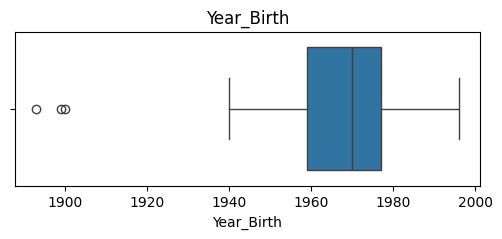

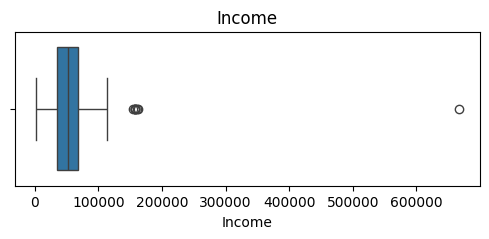

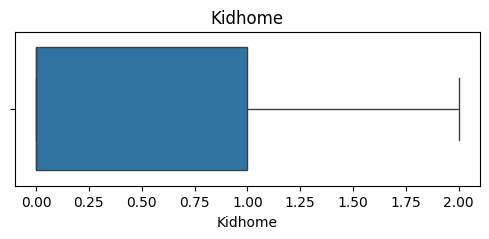

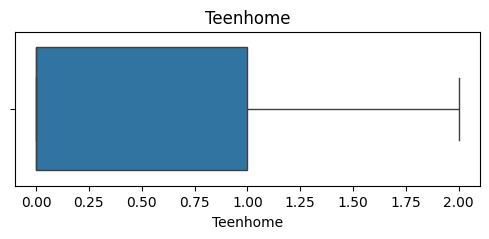

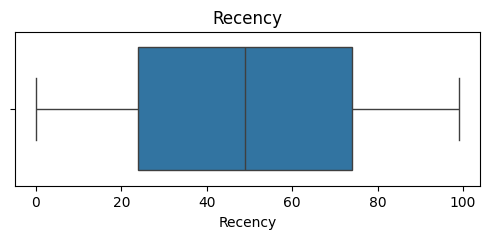

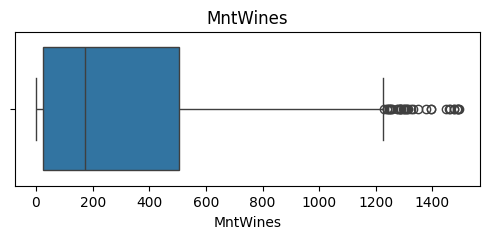

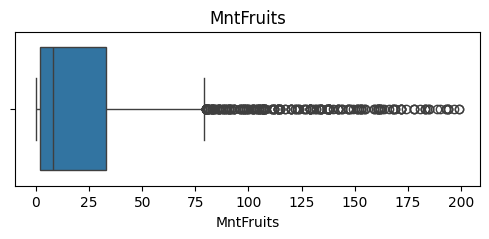

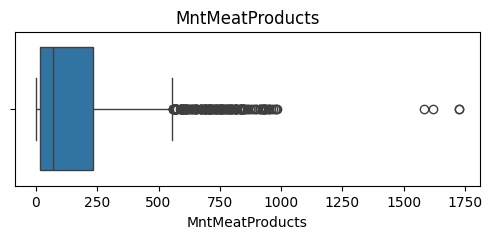

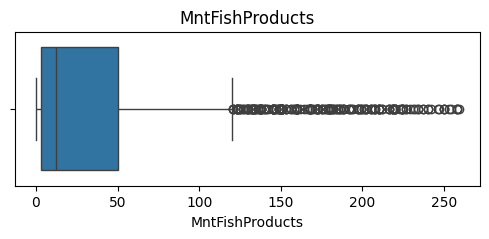

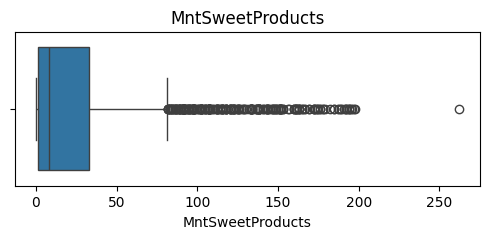

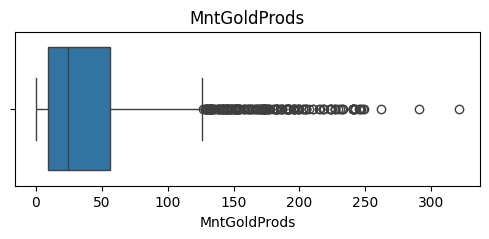

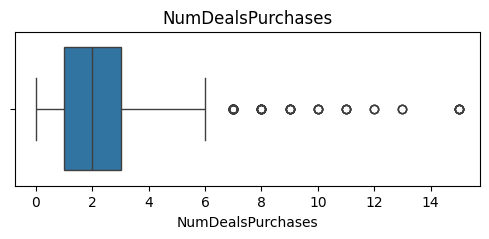

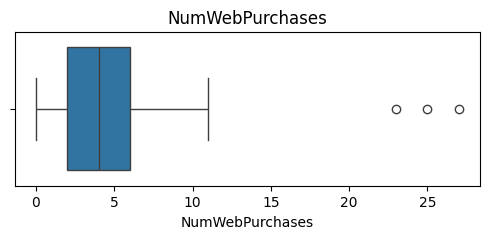

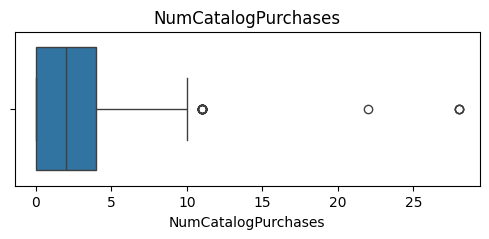

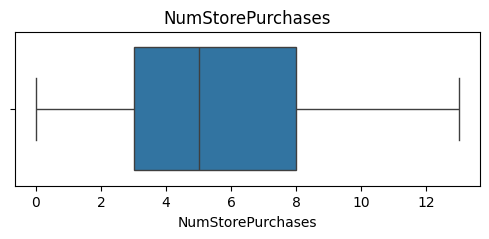

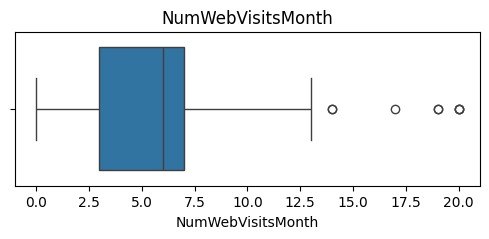

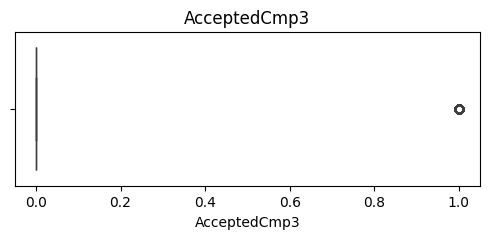

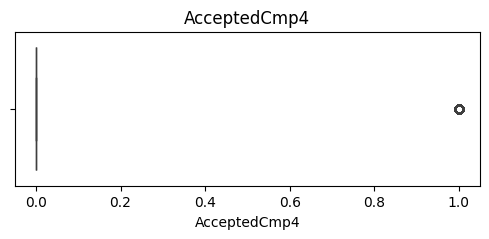

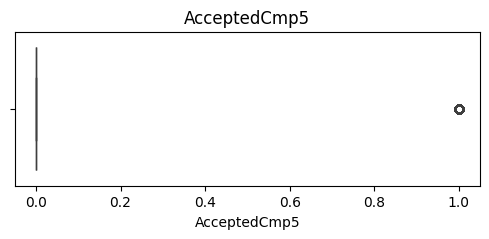

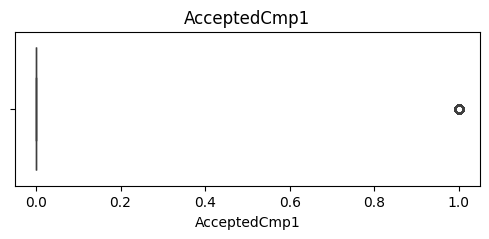

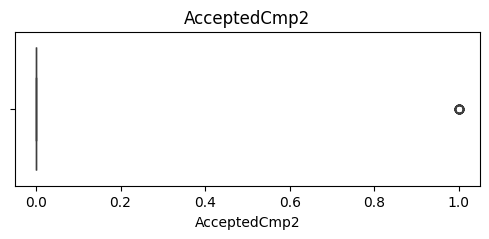

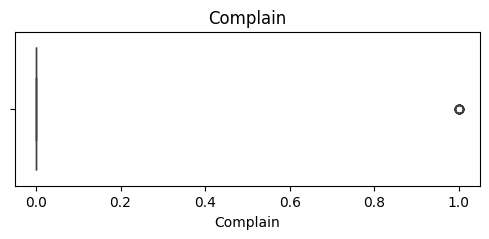

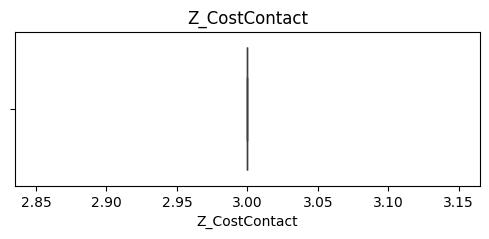

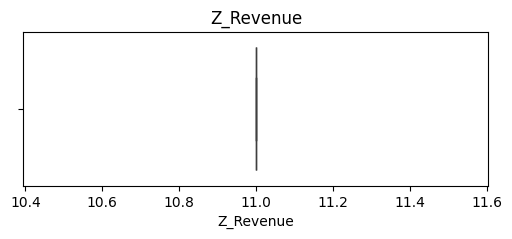

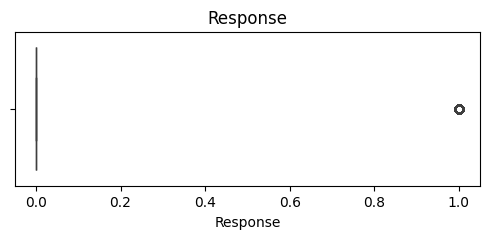

In [17]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [18]:
# Total spending

df["Total_Spent"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

# Total children

df["Total_Children"] = (
    df["Kidhome"] +
    df["Teenhome"]
)

# Customer age

df["Age"] = 2026 - df["Year_Birth"]

In [19]:
df.shape

(2216, 32)

In [20]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Total_Spent,Total_Children,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,3,11,1,1617,0,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,3,11,0,27,2,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,3,11,0,776,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,3,11,0,53,1,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,3,11,0,422,1,45


In [21]:
df.dropna(inplace=True)

In [22]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [23]:
df["Income"] = df["Income"].fillna(df["Income"].mean())

In [24]:
imputer = KNNImputer(n_neighbors=5)

num_cols = df.select_dtypes(include=np.number).columns

df[num_cols] = imputer.fit_transform(df[num_cols])

In [25]:
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

0


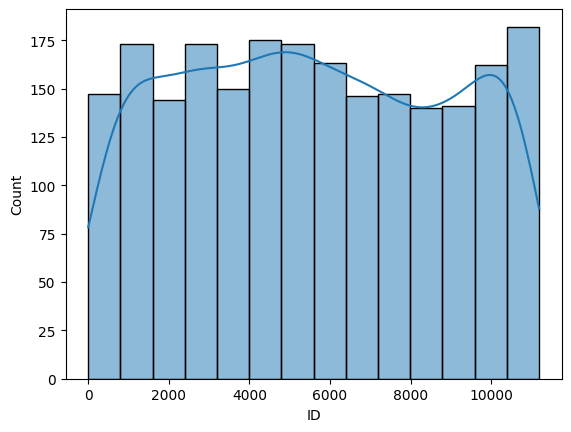

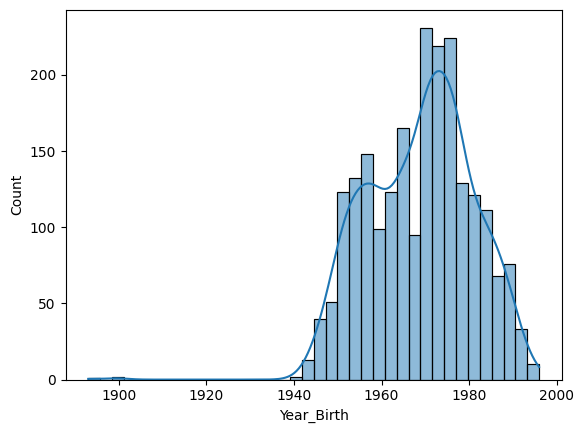

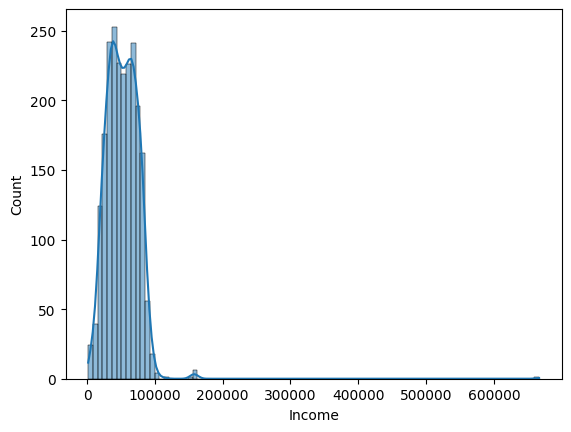

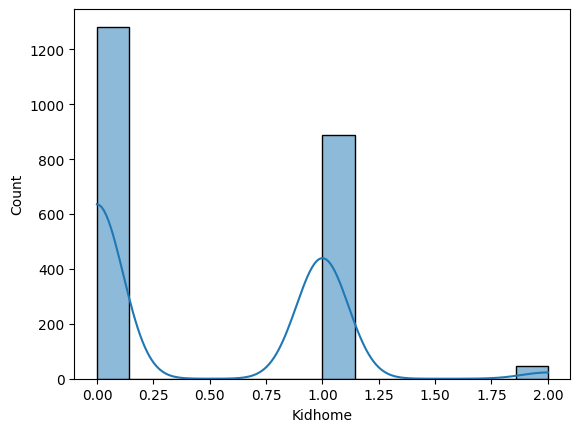

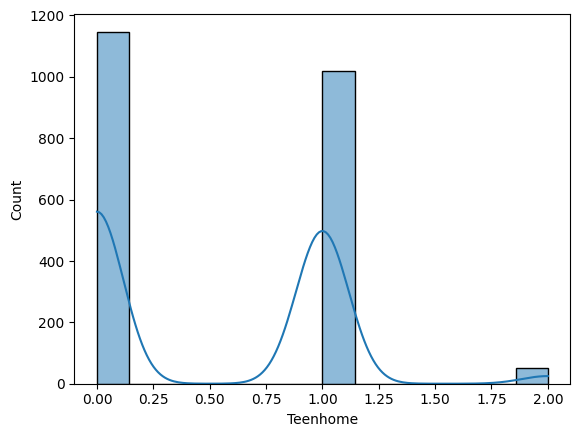

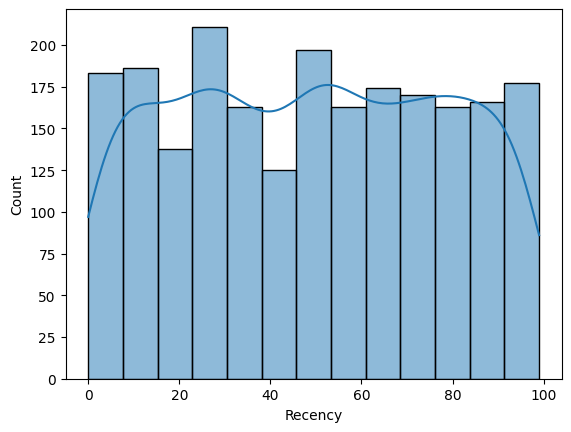

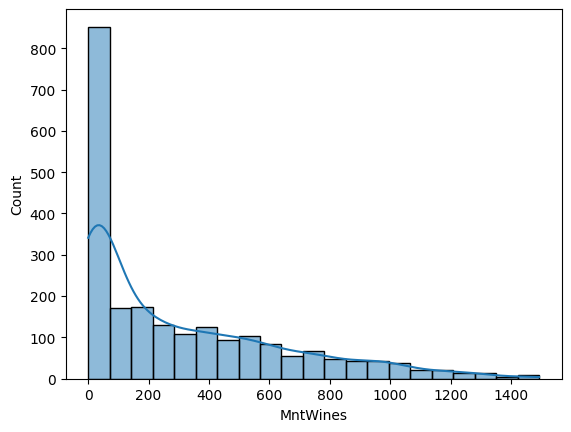

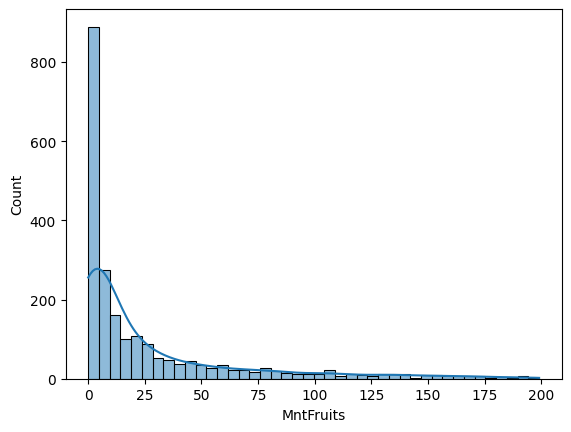

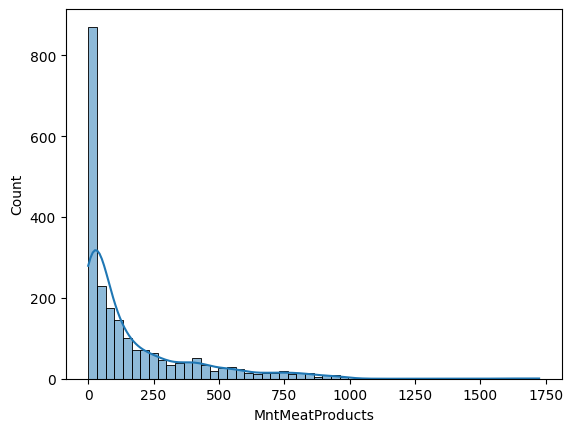

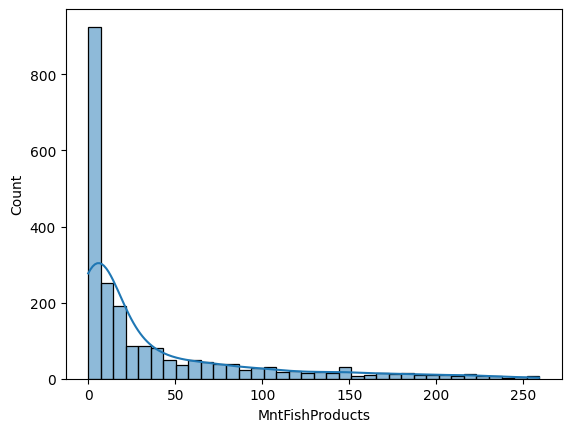

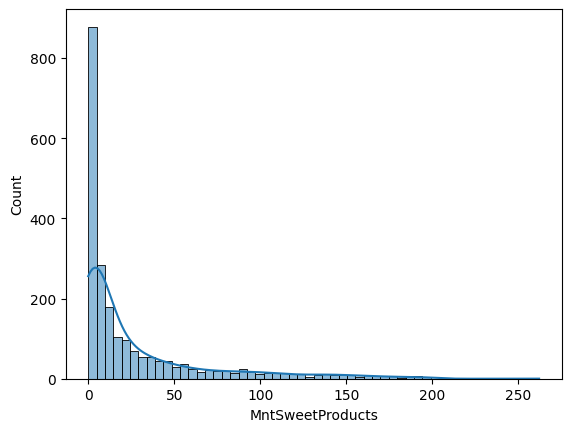

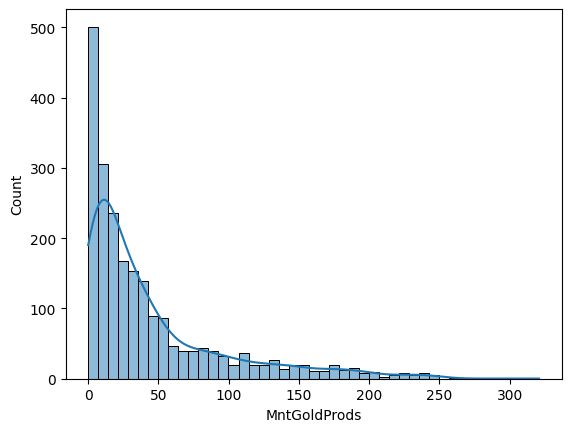

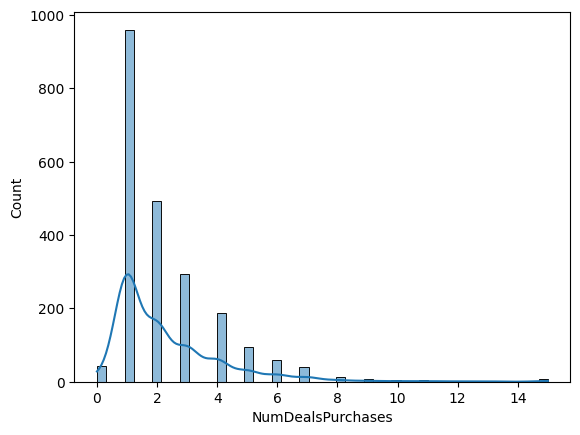

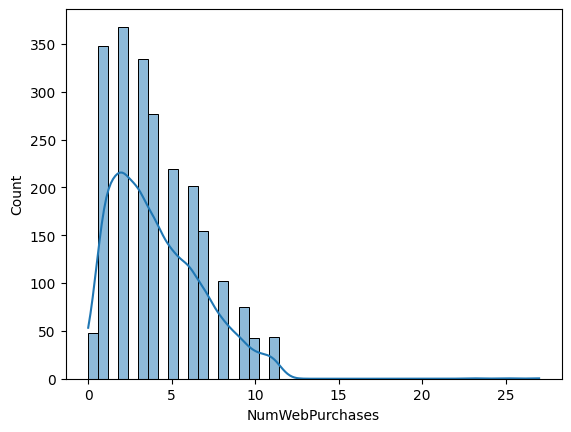

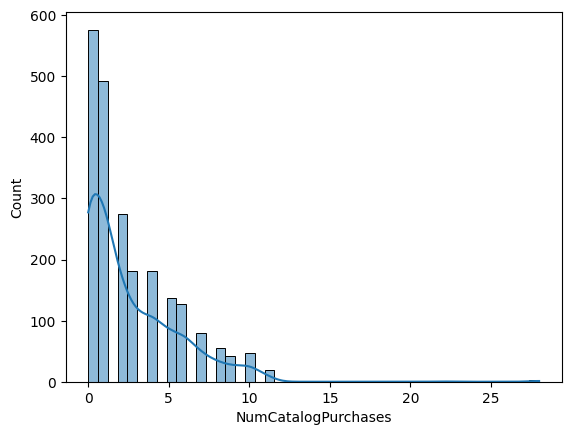

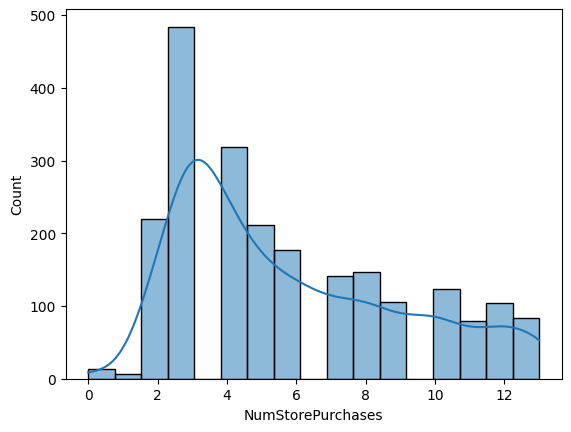

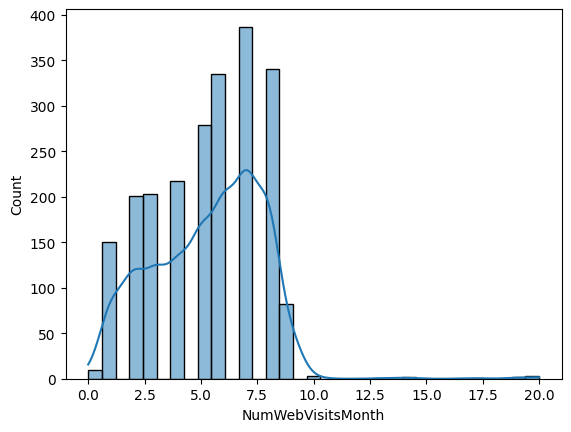

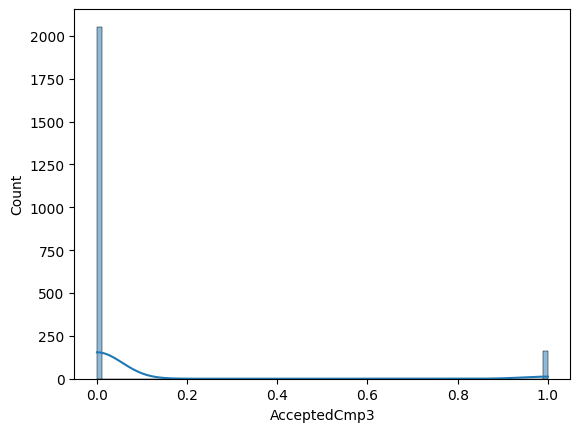

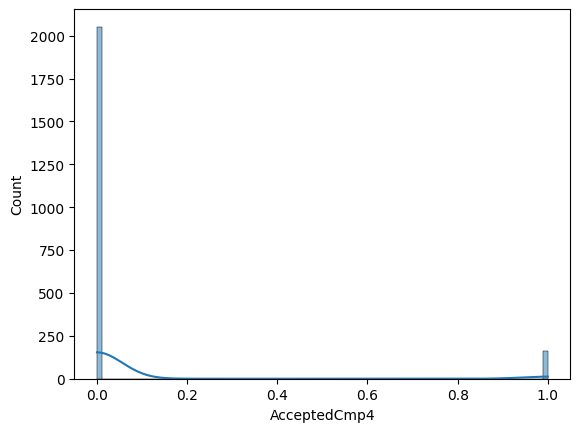

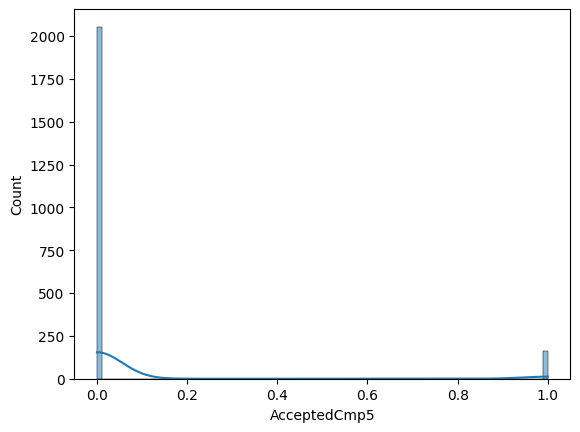

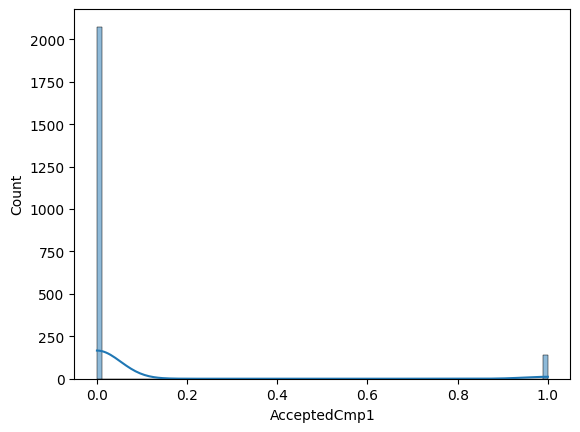

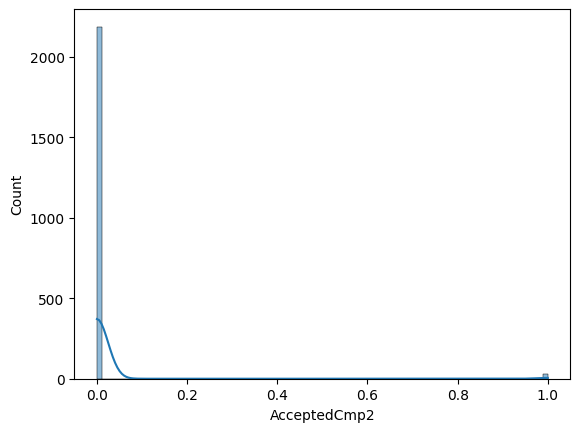

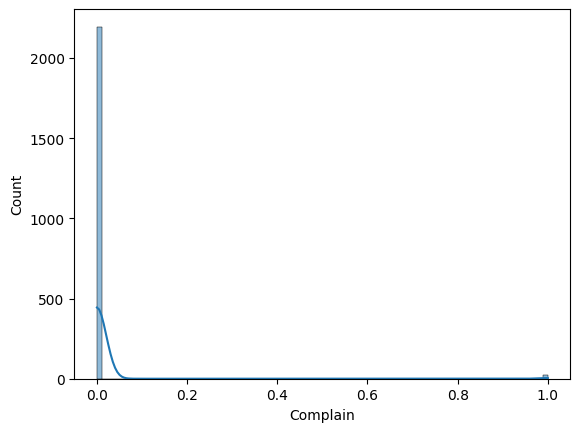

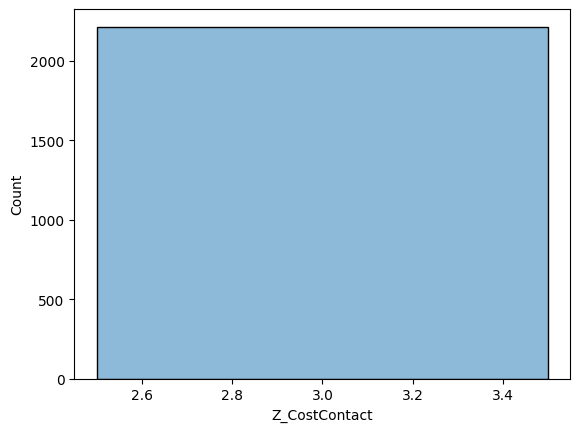

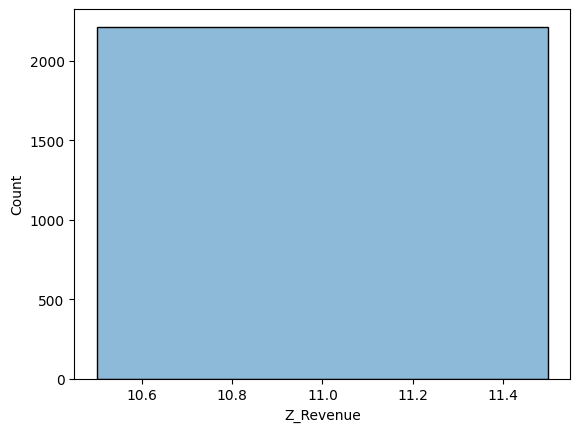

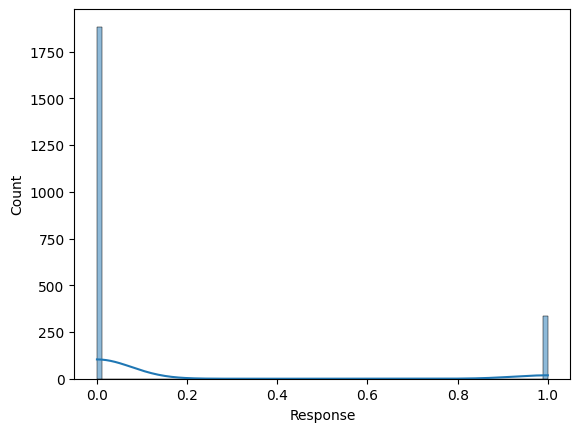

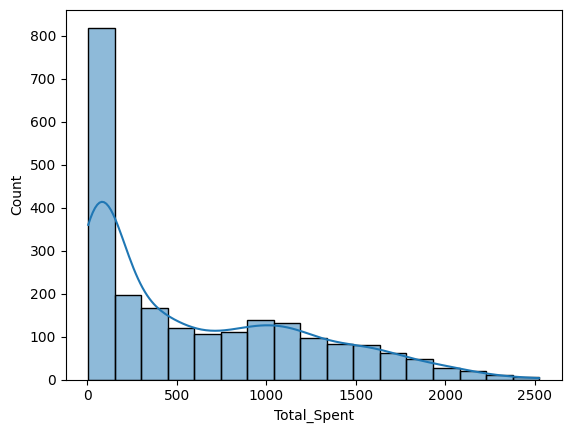

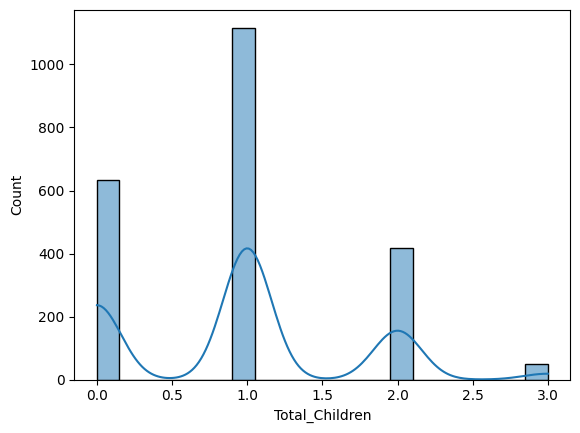

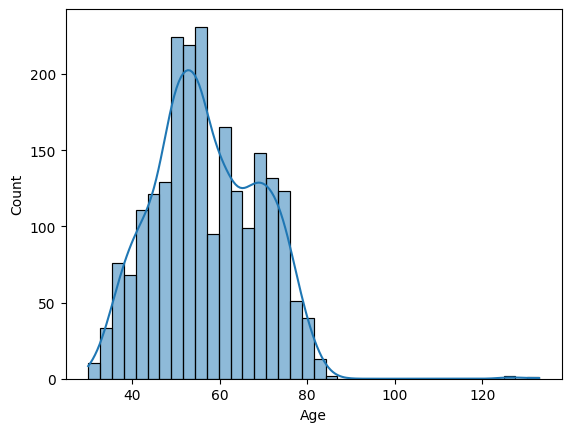

In [26]:
for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.show()

In [27]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(col, len(outliers))

ID 0
Year_Birth 3
Income 8
Kidhome 0
Teenhome 0
Recency 0
MntWines 35
MntFruits 246
MntMeatProducts 174
MntFishProducts 222
MntSweetProducts 246
MntGoldProds 205
NumDealsPurchases 84
NumWebPurchases 3
NumCatalogPurchases 23
NumStorePurchases 0
NumWebVisitsMonth 8
AcceptedCmp3 163
AcceptedCmp4 164
AcceptedCmp5 162
AcceptedCmp1 142
AcceptedCmp2 30
Complain 21
Z_CostContact 0
Z_Revenue 0
Response 333
Total_Spent 3
Total_Children 50
Age 3


In [28]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df[col] = np.clip(
        df[col],
        lower,
        upper
    )

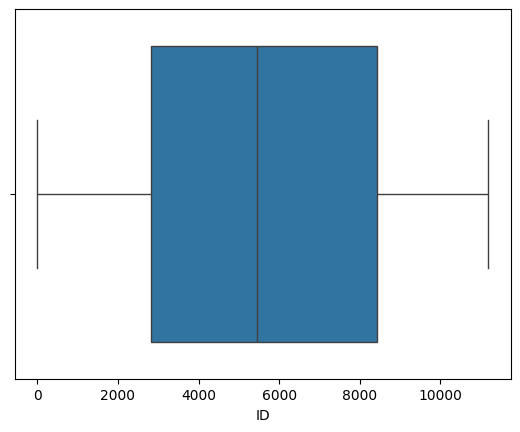

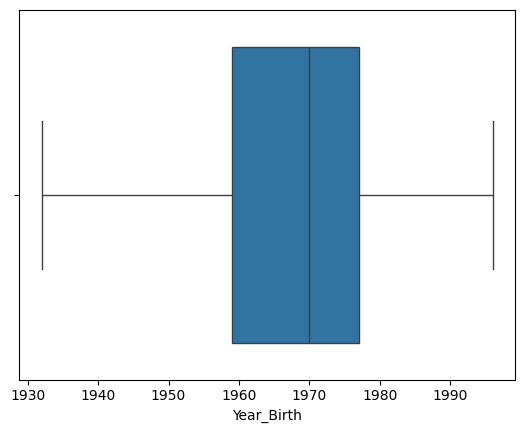

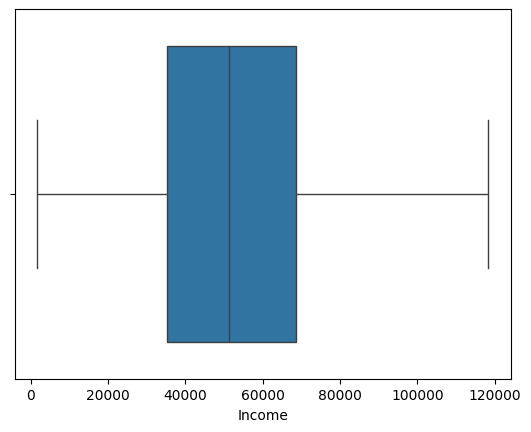

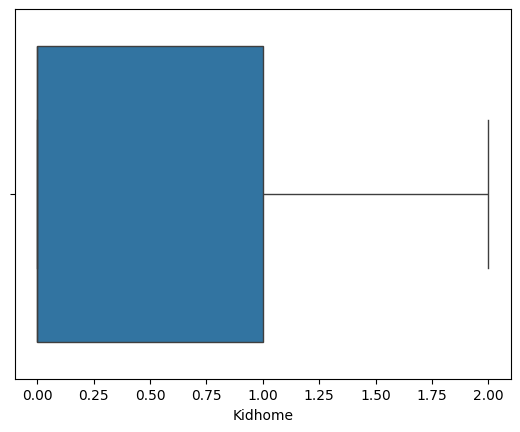

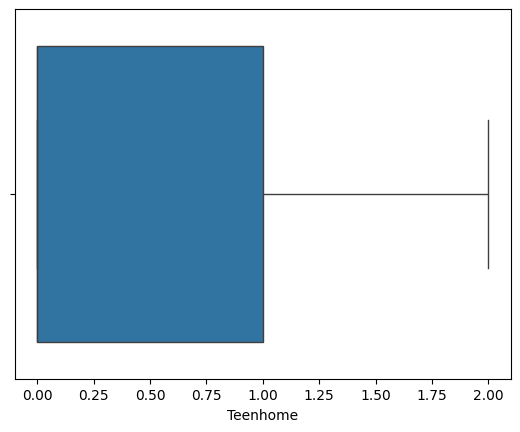

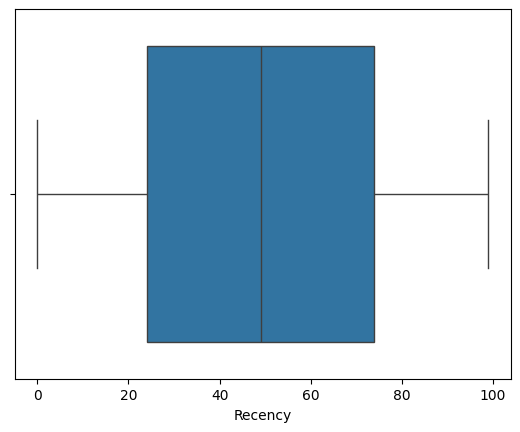

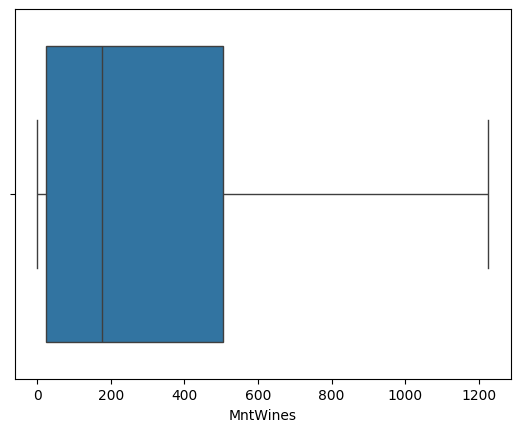

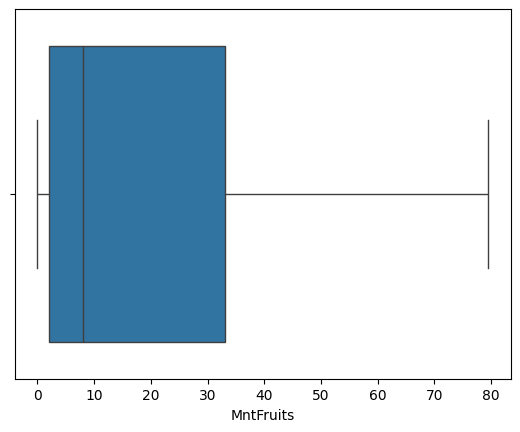

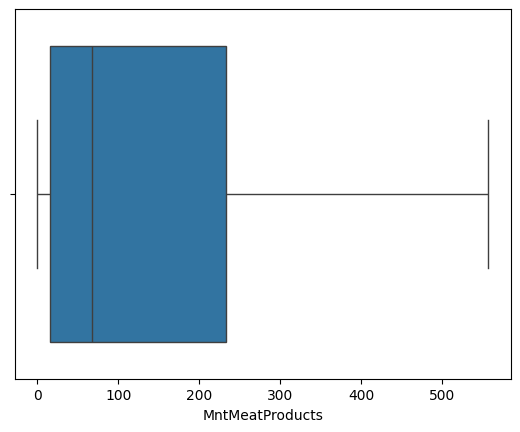

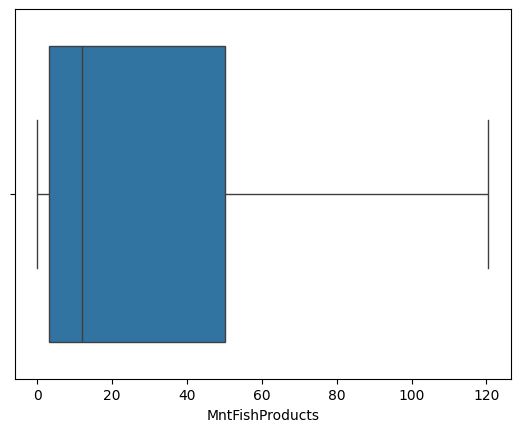

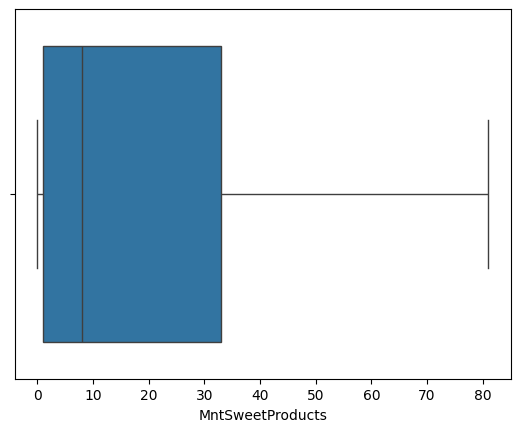

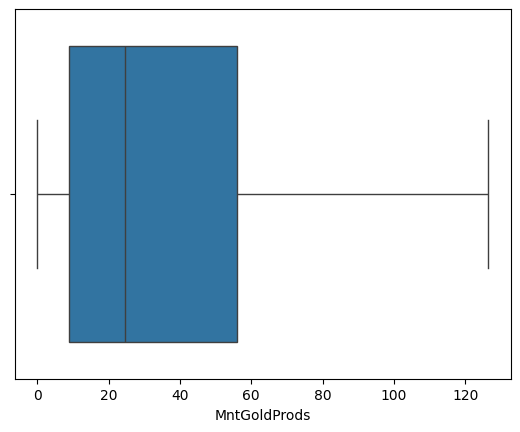

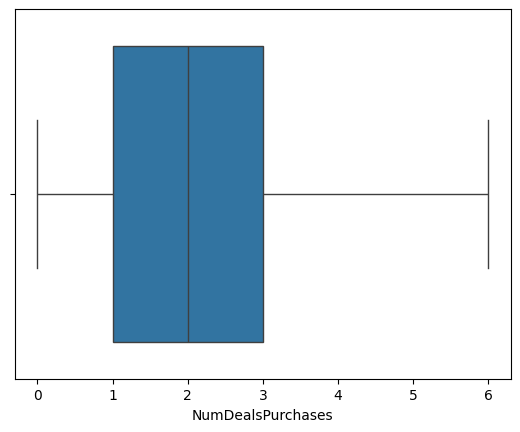

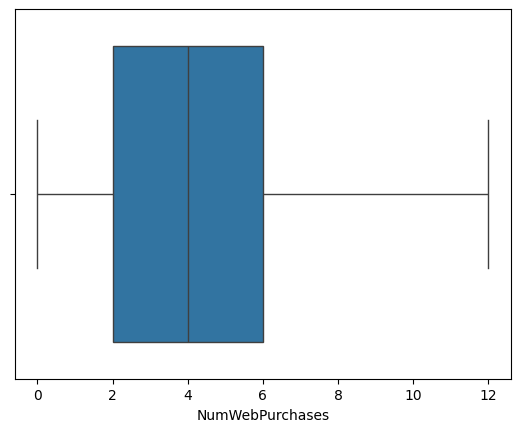

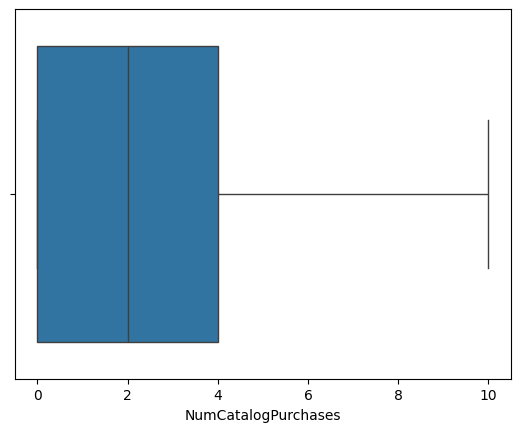

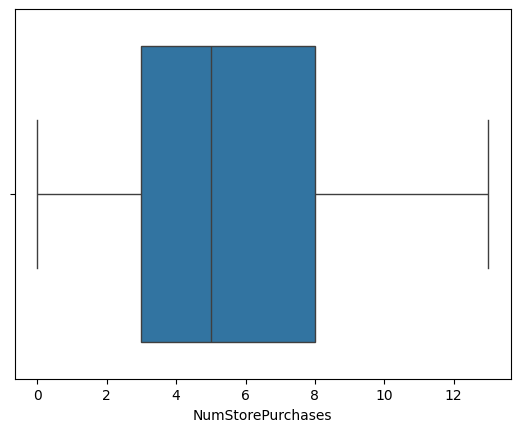

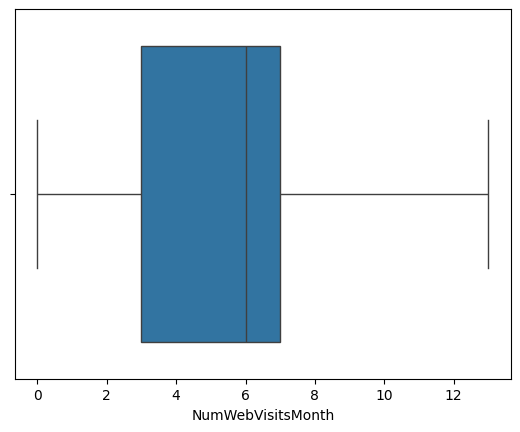

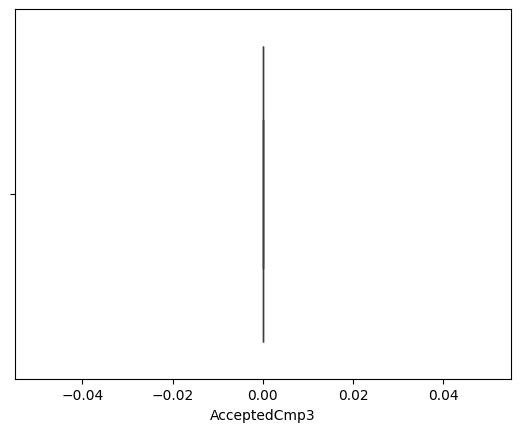

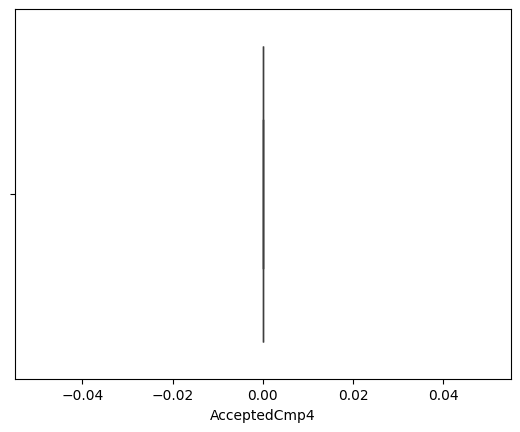

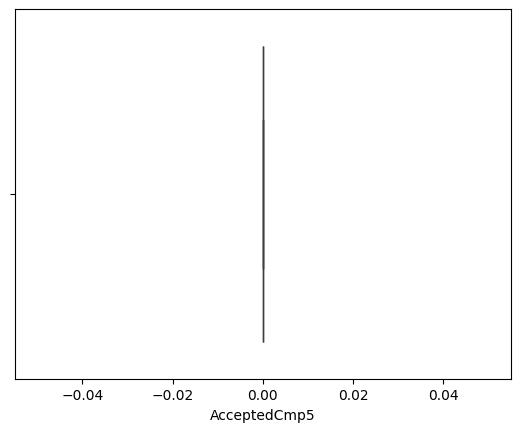

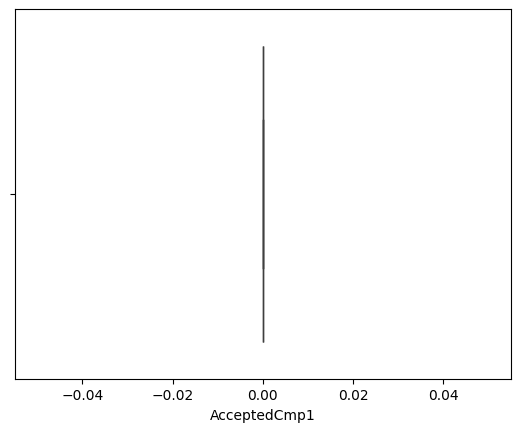

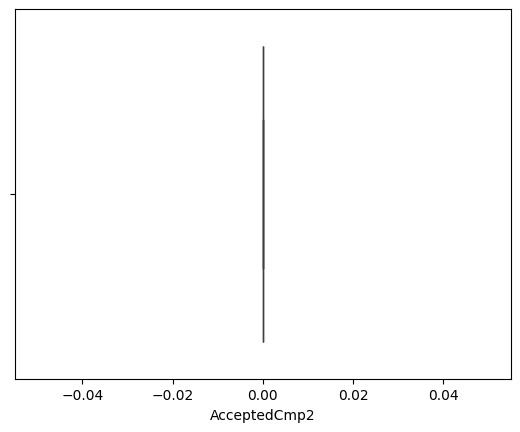

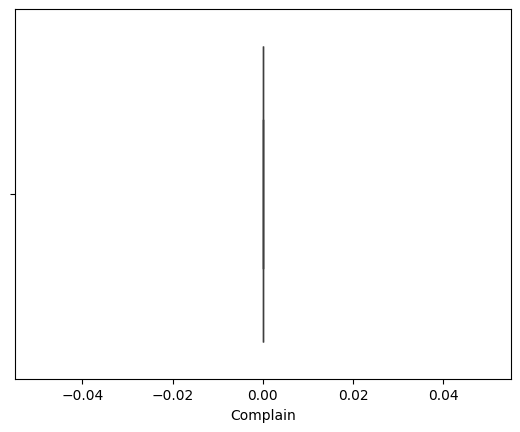

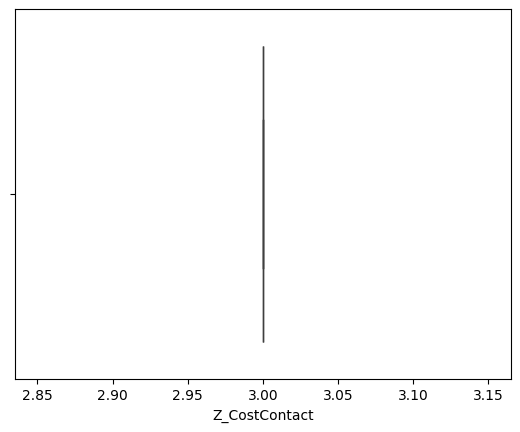

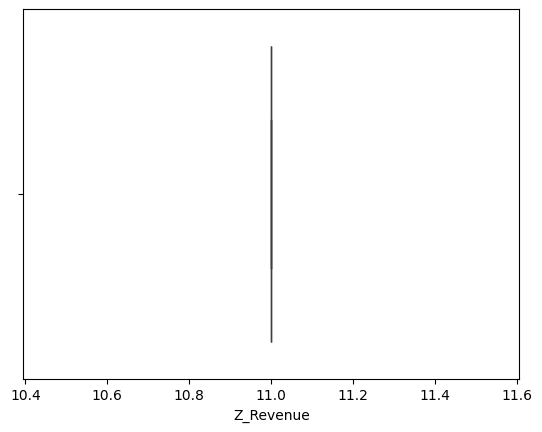

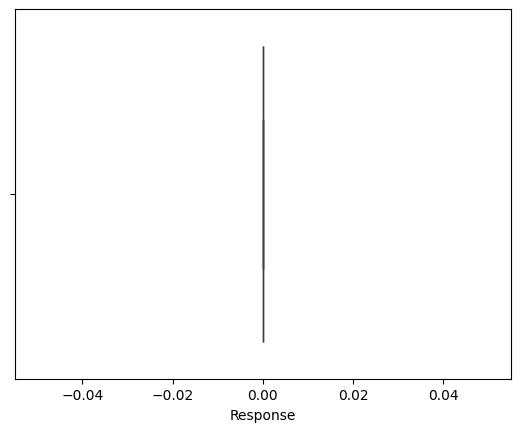

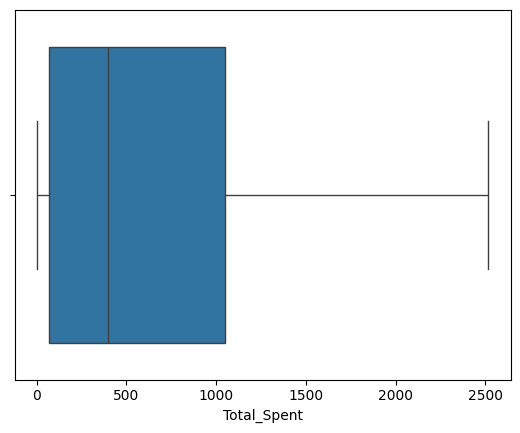

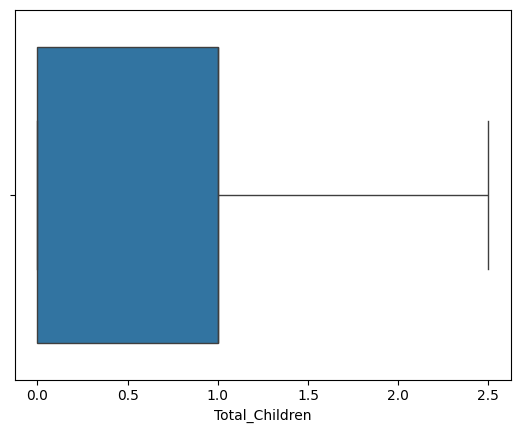

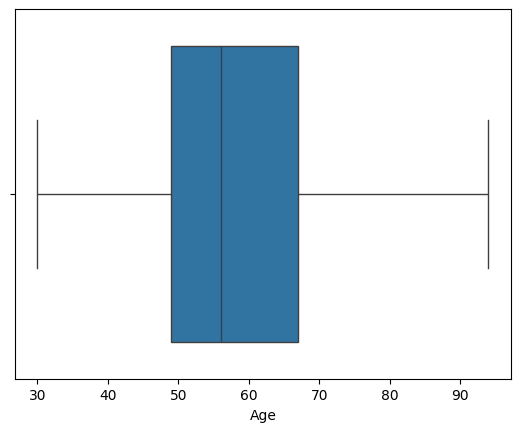

In [29]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.show()

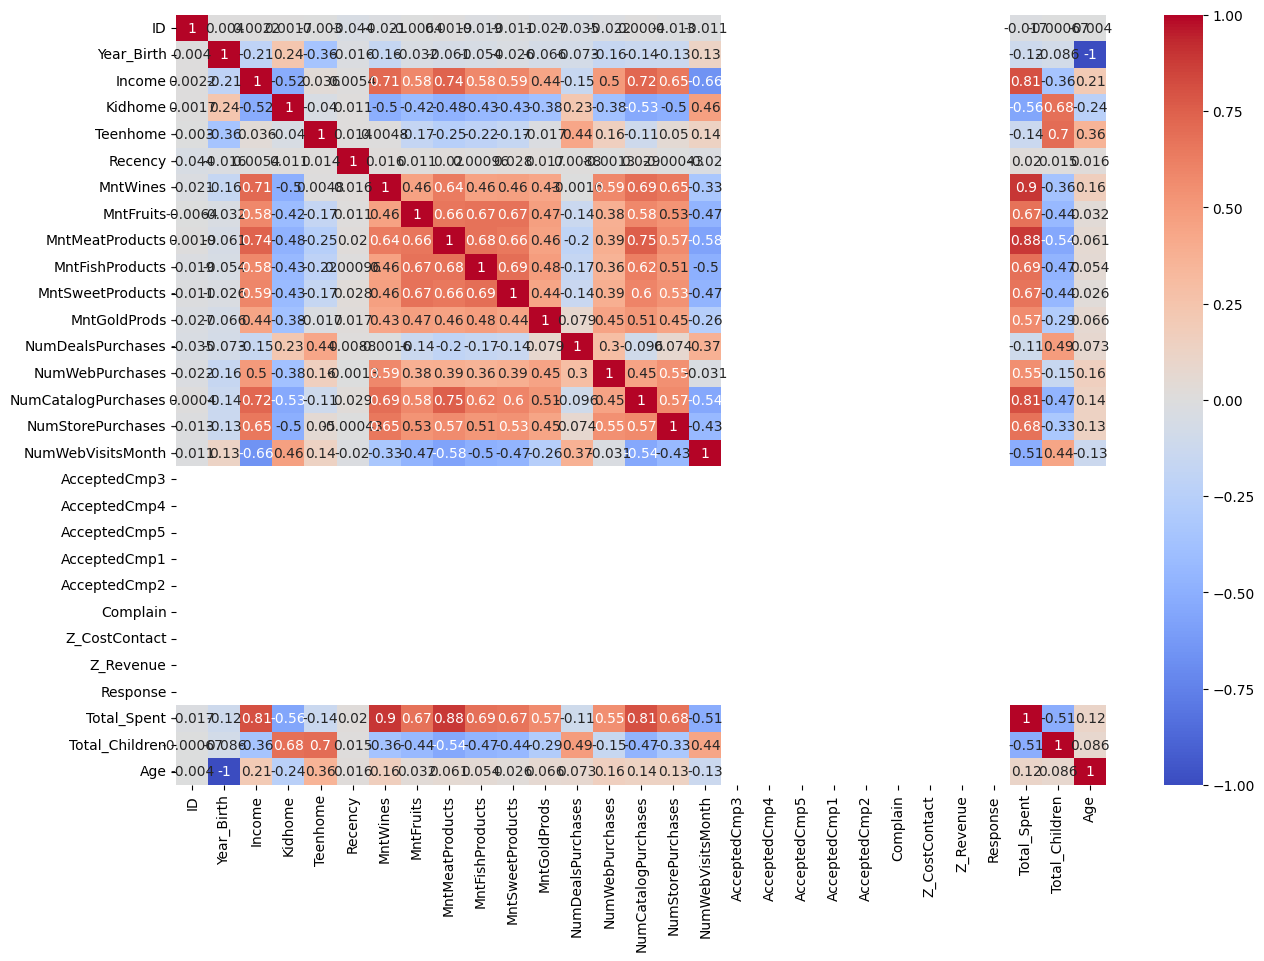

In [33]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [40]:
#Feature Engineering
# Feature 1
df["Total_Spent"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)

# Feature 2
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

# Feature 3
df["Age"] = 2026 - df["Year_Birth"]

# Feature 4 (optional, looks good in report)
df["Total_Purchases"] = (
    df["NumWebPurchases"]
    + df["NumCatalogPurchases"]
    + df["NumStorePurchases"]
)

In [41]:
df[["Age","Total_Children","Total_Spent","Total_Purchases"]].head()

,Age,Total_Children,Total_Spent,Total_Purchases
0,69.0,0.0,1550.0,22.0
1,72.0,2.0,27.0,4.0
2,61.0,0.0,776.0,20.0
3,42.0,1.0,53.0,6.0
4,45.0,1.0,422.0,14.0


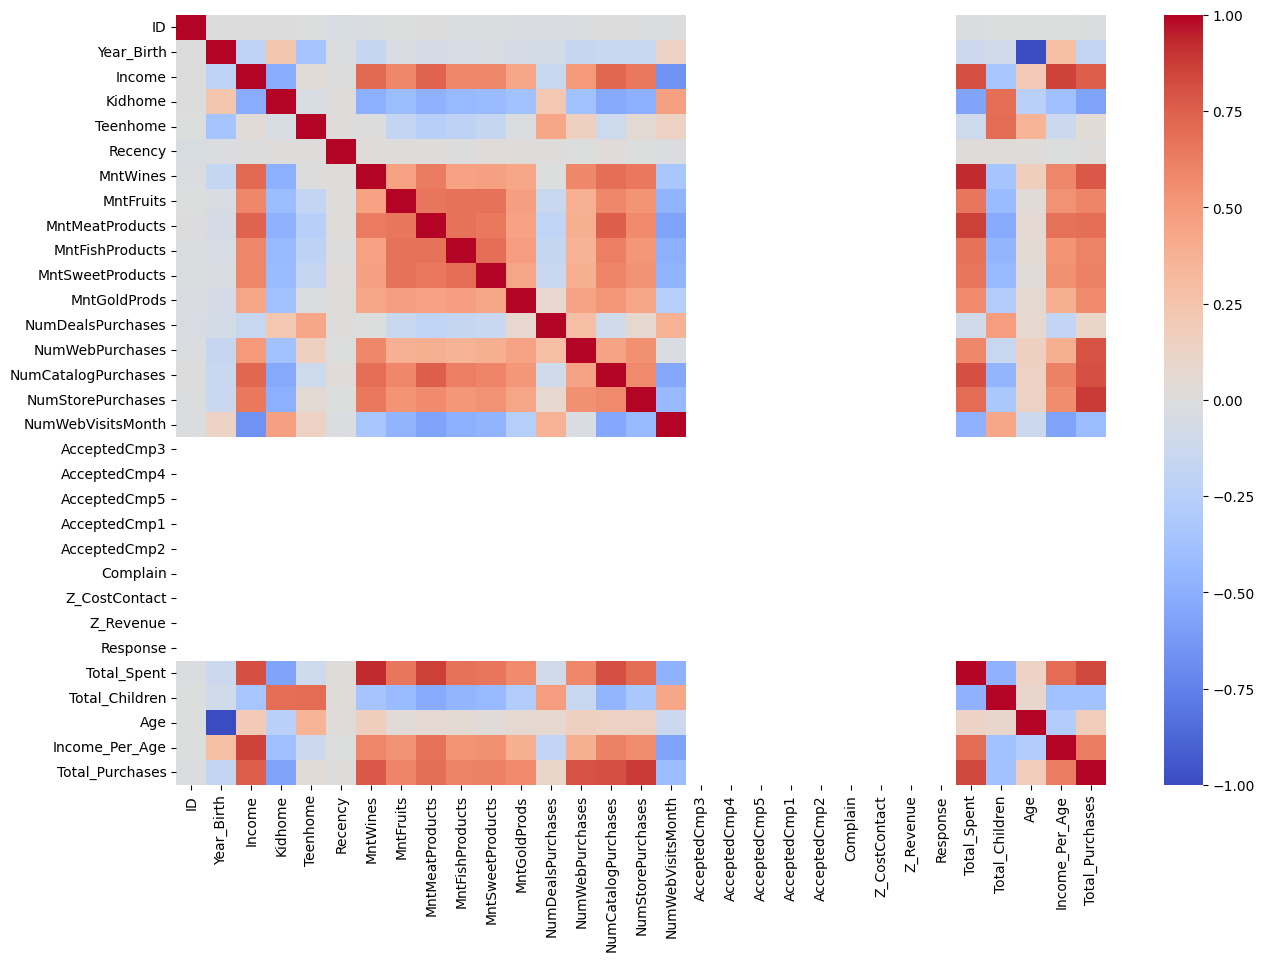

In [42]:
# Numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

# Correlation Heatmap
plt.figure(figsize=(15,10))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm')
plt.show()

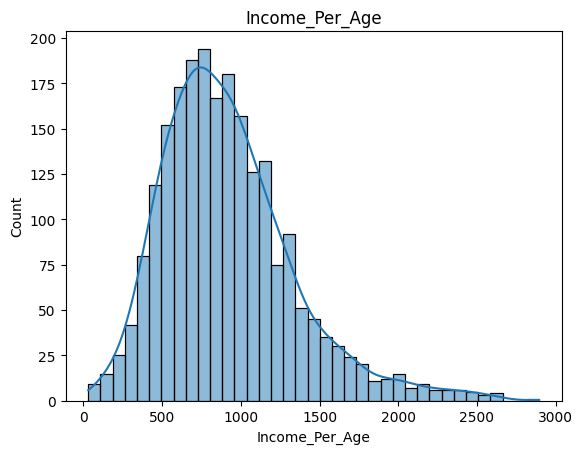

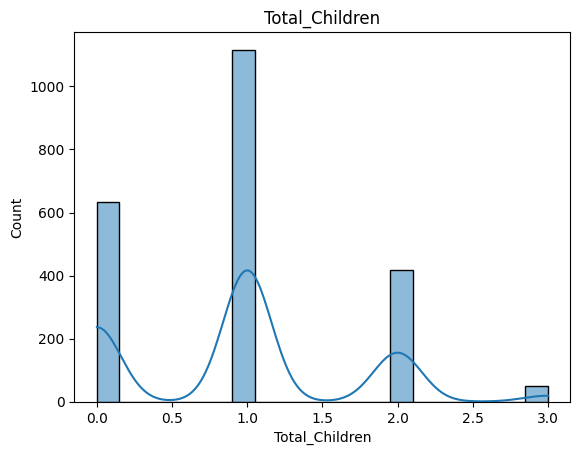

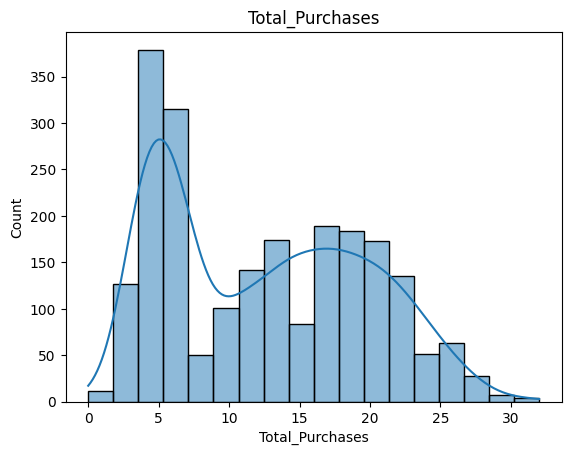

In [44]:
new_features = [
    "Income_Per_Age",
    "Total_Children",
    "Total_Purchases"
]
for col in new_features:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [45]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [46]:
corr_matrix = df.corr().abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr = [
    column
    for column in upper.columns
    if any(upper[column] > 0.80)
]

print(high_corr)

['Total_Spent', 'Age', 'Income_Per_Age', 'Total_Purchases']


In [47]:
df.drop(
    columns=high_corr,
    inplace=True
)

In [48]:
print(df.shape)

print(df.isnull().sum().sum())

print(df.duplicated().sum())

(2216, 699)
0
0


In [49]:
df.to_csv(
    "cleaned_dataset.csv",
    index=False
)